# FedLPPA Prostate MRI — Full Run (6 Sites, 6000 Iterations)

Paper: https://arxiv.org/abs/2402.17502  
Code: https://github.com/llmir/FedLPPA

**Dataset:** Pre-processed H5 files shared via Google Drive (Prostate_h5 folder)  
**Sites:** Domain 1-6 (all 6 domains including I2CVB)  
**Strategy:** FedUniV2.1  

> Run cells top to bottom. After Cell 2 the runtime restarts automatically — continue from Cell 3 after restart.

## Step 1 — Mount Drive and set dataset path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os

# The Prostate_h5 folder is shared with you.
# First add a shortcut to your Drive:
#   Go to: Shared with me > Prostate_h5 > right click > Organise > Add shortcut > My Drive
# Then this path will work:
H5_BASE = "/content/drive/MyDrive/Prostate_h5"

# Verify all 6 domains exist
for dom in ["Domain1","Domain2","Domain3","Domain4","Domain5","Domain6"]:
    path = os.path.join(H5_BASE, dom)
    if os.path.exists(path):
        tr = len(os.listdir(os.path.join(path,"train"))) if os.path.exists(os.path.join(path,"train")) else 0
        te = len(os.listdir(os.path.join(path,"test")))  if os.path.exists(os.path.join(path,"test"))  else 0
        print(f"{dom}: {tr} train slices, {te} test slices")
    else:
        print(f"{dom}: MISSING")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Domain1: 340 train slices, 81 test slices
Domain2: 297 train slices, 87 test slices
Domain3: 372 train slices, 96 test slices
Domain4: 134 train slices, 41 test slices
Domain5: 193 train slices, 68 test slices
Domain6: 122 train slices, 36 test slices


## Step 2 — Install dependencies
This cell restarts the runtime automatically. Continue from Step 3 after restart.

In [ ]:
import subprocess, sys

pkgs = [
    "numpy>=2.0", "scipy>=1.14.0", "scikit-image>=0.22",
    "SimpleITK>=2.3", "h5py>=3.10", "pydicom>=2.4",
    "opencv-python-headless>=4.9", "pandas>=2.0",
    "matplotlib>=3.8", "seaborn", "tqdm",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U"] + pkgs, check=True)
print("Base packages installed. Restarting...")
import os, signal
os.kill(os.getpid(), signal.SIGKILL)


## Step 3 — Sanity check (run after restart)

In [1]:
import numpy as np, scipy, cv2, h5py
print(f"numpy  {np.__version__}")
print(f"scipy  {scipy.__version__}")
print(f"cv2    {cv2.__version__}")
print(f"h5py   {h5py.__version__}")
print("All imports OK.")


numpy  2.4.6
scipy  1.17.1
cv2    4.13.0
h5py   3.16.0
All imports OK.


## Step 4 — EDA on H5 Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Domain     Info                                  Train   Test
  Domain1    NCI-ISBI Siemens 3T     | block         340     81
  Domain2    NCI-ISBI Philips 1.5T   | keypoint      297     87
  Domain3    I2CVB                   | scribble      372     96
  Domain4    PROMISE12 Siemens-UCL   | keypoint      134     41
  Domain5    PROMISE12 GE-BIDMC      | scribble      193     68
  Domain6    PROMISE12 Siemens-HK    | box           122     36
-----------------------------------------------------------------
  TOTAL                                             1458    409

H5 keys per domain (from first train file):
  Domain1: keys=['block', 'image', 'mask']  image=(384, 384) dtype=float32  mask unique=[0 1]
  Domain2: keys=['image', 'keypoint', 'mask']  image=(384, 384) dtype=float32  mask unique=[0 1]
  Domain3: keys=['image', 'mask', 'scribble']  image=(384

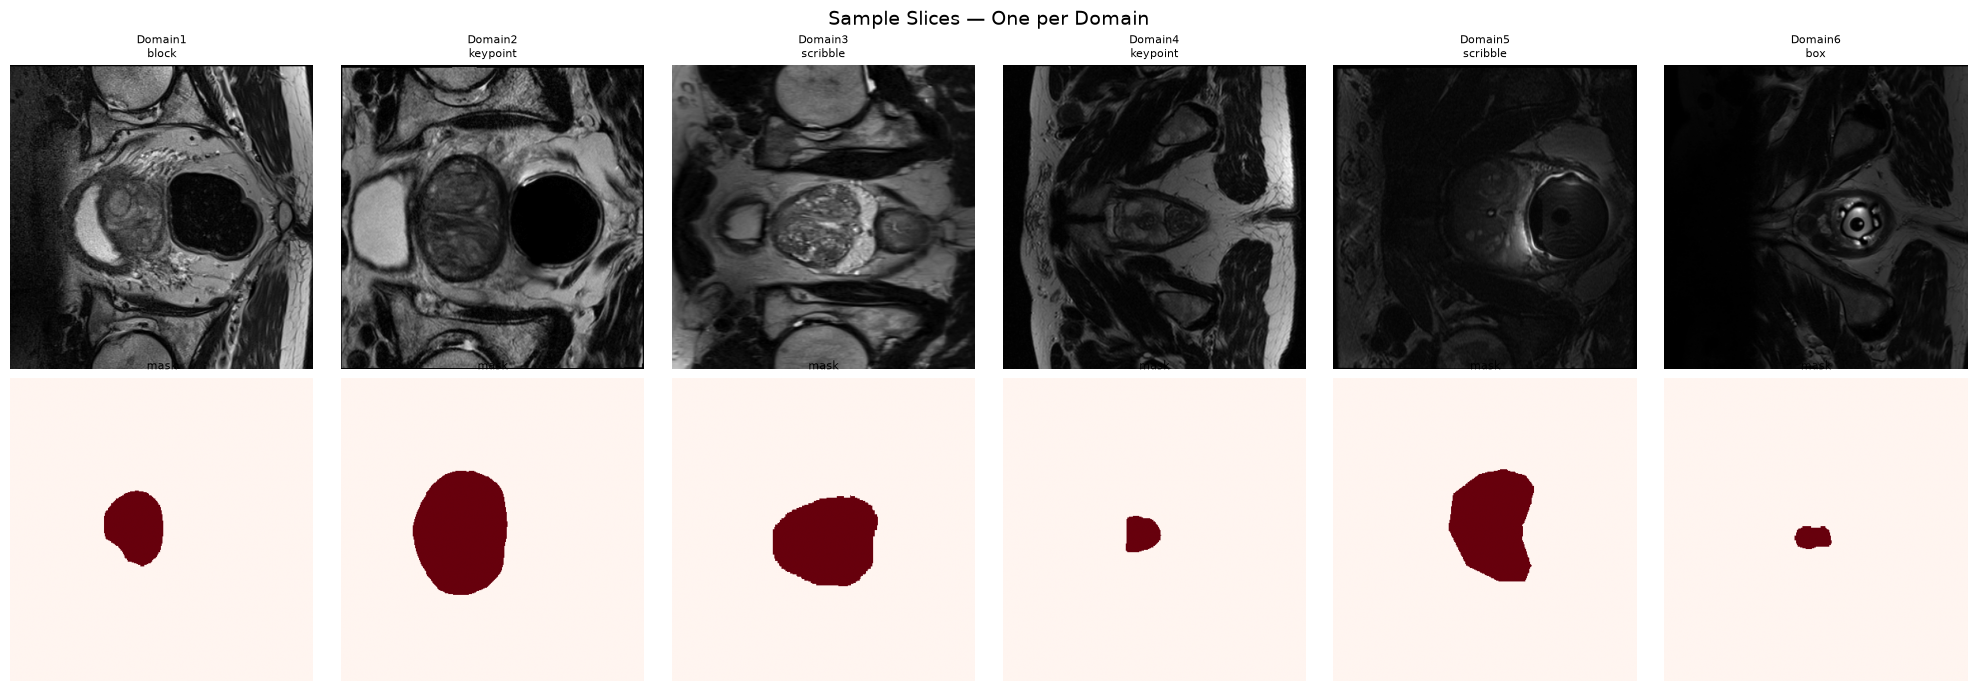


Annotation keys present in train files:
  Domain1 [OK]: present=['block']  missing=['keypoint', 'scribble', 'scribble_noisy', 'box']
  Domain2 [OK]: present=['keypoint']  missing=['block', 'scribble', 'scribble_noisy', 'box']
  Domain3 [OK]: present=['scribble']  missing=['block', 'keypoint', 'scribble_noisy', 'box']
  Domain4 [OK]: present=['keypoint']  missing=['block', 'scribble', 'scribble_noisy', 'box']
  Domain5 [OK]: present=['scribble']  missing=['block', 'keypoint', 'scribble_noisy', 'box']
  Domain6 [OK]: present=['box']  missing=['block', 'keypoint', 'scribble', 'scribble_noisy']


In [6]:
import os, glob, h5py, cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

H5_BASE = "/content/drive/MyDrive/Prostate_h5"
DOMAINS = ["Domain1","Domain2","Domain3","Domain4","Domain5","Domain6"]

# Updated to match actual annotation keys in the H5 files
DOMAIN_INFO = {
    "Domain1": "NCI-ISBI Siemens 3T     | block",
    "Domain2": "NCI-ISBI Philips 1.5T   | keypoint",
    "Domain3": "I2CVB                   | scribble",
    "Domain4": "PROMISE12 Siemens-UCL   | keypoint",
    "Domain5": "PROMISE12 GE-BIDMC      | scribble",   # was scribble_noisy
    "Domain6": "PROMISE12 Siemens-HK    | box",        # was block
}

print("=" * 65)
print(f"  {'Domain':<10} {'Info':<35} {'Train':>7} {'Test':>6}")
print("=" * 65)
total_train = total_test = 0
for dom in DOMAINS:
    tr_files = glob.glob(os.path.join(H5_BASE, dom, "train", "*.h5"))
    te_files = glob.glob(os.path.join(H5_BASE, dom, "test",  "*.h5"))
    total_train += len(tr_files)
    total_test  += len(te_files)
    print(f"  {dom:<10} {DOMAIN_INFO[dom]:<35} {len(tr_files):>7} {len(te_files):>6}")
print("-" * 65)
print(f"  {'TOTAL':<46} {total_train:>7} {total_test:>6}")
print("=" * 65)

print("\nH5 keys per domain (from first train file):")
for dom in DOMAINS:
    files = glob.glob(os.path.join(H5_BASE, dom, "train", "*.h5"))
    if not files: print(f"  {dom}: no files"); continue
    with h5py.File(files[0]) as f:
        keys = list(f.keys())
        img  = f["image"][:]
        msk  = f["mask"][:]
    print(f"  {dom}: keys={keys}  image={img.shape} dtype={img.dtype}  "
          f"mask unique={np.unique(msk)}")

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Sample Slices — One per Domain", fontsize=14)
for idx, dom in enumerate(DOMAINS):
    files = sorted(glob.glob(os.path.join(H5_BASE, dom, "train", "*.h5")))
    if not files: continue
    mid = files[len(files)//2]
    with h5py.File(mid) as f:
        img = f["image"][:]
        msk = f["mask"][:]
    axes[0][idx].imshow(img, cmap="gray")
    axes[0][idx].set_title(f"{dom}\n{DOMAIN_INFO[dom].split('|')[1].strip()}", fontsize=8)
    axes[0][idx].axis("off")
    axes[1][idx].imshow(msk, cmap="Reds")
    axes[1][idx].set_title("mask", fontsize=8)
    axes[1][idx].axis("off")
plt.tight_layout()
plt.show()

print("\nAnnotation keys present in train files:")
ann_keys = ["block","keypoint","scribble","scribble_noisy","box"]
for dom in DOMAINS:
    files = glob.glob(os.path.join(H5_BASE, dom, "train", "*.h5"))
    if not files: continue
    with h5py.File(files[0]) as f:
        present = [k for k in ann_keys if k in f]
        missing = [k for k in ann_keys if k not in f]
    status = "OK" if len(present) == 1 else "CHECK"
    print(f"  {dom} [{status}]: present={present}  missing={missing}")

## Step 5 — Clone FedLPPA repository

In [7]:
import os
if not os.path.exists("/content/FedLPPA"):
    !git clone https://github.com/llmir/FedLPPA.git
else:
    print("Already cloned.")
%cd /content/FedLPPA


Cloning into 'FedLPPA'...
remote: Enumerating objects: 653, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 653 (delta 24), reused 0 (delta 0), pack-reused 609 (from 1)
Receiving objects: 100% (653/653), 6.62 MiB | 76.13 MiB/s, done.
Resolving deltas: 100% (309/309), done.
/content/FedLPPA


## Step 6 — Install remaining packages

In [9]:
import os, subprocess, sys

# flwr — use 1.4.0 (1.0.0 does not support Python 3.12)
!pip install -q "flwr==1.4.0" "grpcio>=1.59.0,<2.0" "protobuf>=3.20.0,<4.0"

# Re-upgrade numpy after flwr downgrades it
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "numpy>=2.0", "scipy>=1.14.0"], check=True)

# Remaining FedLPPA dependencies
!pip install -q efficientnet-pytorch tensorboardX info-nce-pytorch medpy

# Try tree filter wheel (Python 3.9 only — will fail on 3.12, patched below)
os.chdir("/content/FedLPPA")
!pip install tree_filter-0.1-cp39-cp39-linux_x86_64.whl -q 2>/dev/null || \
    echo "tree_filter wheel skipped (Python 3.12 incompatible — patched below)"

import flwr as fl, numpy as np, scipy
print(f"flwr {fl.__version__}  |  numpy {np.__version__}  |  scipy {scipy.__version__}")

from flwr.common import (
    GetParametersRes, Status, FitRes, EvaluateRes,
    ndarrays_to_parameters, parameters_to_ndarrays,
    GetPropertiesIns, GetPropertiesRes
)
print("All flwr symbols OK.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 181.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
googleapis-common-protos 1.75.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
grpc-google-iam-v1 0.14.4 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompa

## Step 7 — Apply all source code patches
This cell applies every fix that was needed to get FedLPPA running on Python 3.12 with prostate MRI data.

In [10]:
import os, re

CODE = "/content/FedLPPA/code_v4"

# ── Patch 1: stub out flwr tensorboard ───────────────────────────
tb = "/usr/local/lib/python3.12/dist-packages/flwr/server/utils/tensorboard.py"
with open(tb, "w") as f:
    f.write("# stubbed\ndef tensorboard(*args, **kwargs):\n    pass\n")
print("Patch 1 done: flwr tensorboard stub")

# ── Patch 2: tree_filter try/except in all three common files ────
TREE_PATCH = (
    "try:\n"
    "    from utils.TreeEnergyLoss.kernels.lib_tree_filter"
    ".modules.tree_filter import MinimumSpanningTree\n"
    "    from utils.TreeEnergyLoss.kernels.lib_tree_filter"
    ".modules.tree_filter import TreeFilter2D\n"
    "    TREE_FILTER_AVAILABLE = True\n"
    "except Exception:\n"
    "    MinimumSpanningTree = None\n"
    "    TreeFilter2D = None\n"
    "    TREE_FILTER_AVAILABLE = False\n"
)
BAD_1 = (
    "from utils.TreeEnergyLoss.kernels.lib_tree_filter"
    ".modules.tree_filter import MinimumSpanningTree\n"
)
BAD_2 = (
    "from utils.TreeEnergyLoss.kernels.lib_tree_filter"
    ".modules.tree_filter import TreeFilter2D\n"
)
for fname in [
    "flower_common.py",
    "flower_common_v4.py",
    "flower_common_v4_addprostate.py",
]:
    fp = os.path.join(CODE, fname)
    if not os.path.exists(fp):
        continue
    with open(fp) as f:
        src = f.read()
    if "TREE_FILTER_AVAILABLE" in src:
        print(f"Patch 2 already applied: {fname}")
        continue
    src = src.replace(BAD_1, "").replace(BAD_2, TREE_PATCH)
    with open(fp, "w") as f:
        f.write(src)
    print(f"Patch 2 done: tree_filter try/except in {fname}")

# ── Patch 3: TreeEnergyLoss runtime disable ───────────────────────
cv4 = os.path.join(CODE, "flower_common_v4.py")
with open(cv4) as f:
    src = f.read()

OLD3 = "        self.mst_layers = MinimumSpanningTree(TreeFilter2D.norm2_distance)"
NEW3 = (
    "        if not TREE_FILTER_AVAILABLE or TreeFilter2D is None:\n"
    "            self.mst_layers = None\n"
    "            self._disabled = True\n"
    "            return\n"
    "        self._disabled = False\n"
    "        self.mst_layers = MinimumSpanningTree(TreeFilter2D.norm2_distance)"
)
OLD3F = "    def forward(self, prediction, image, low_feats, unlabeled_RoIs, epoch):"
NEW3F = (
    "    def forward(self, prediction, image, low_feats, unlabeled_RoIs, epoch):\n"
    "        if getattr(self, '_disabled', False):\n"
    "            return prediction.sum() * 0.0"
)

changed = False
if OLD3 in src:
    src = src.replace(OLD3, NEW3)
    changed = True
if OLD3F in src:
    src = src.replace(OLD3F, NEW3F)
    changed = True
if changed:
    with open(cv4, "w") as f:
        f.write(src)
    print("Patch 3 done: TreeEnergyLoss runtime disable")
else:
    print("Patch 3 already applied or pattern not found")

# ── Patch 4: GatedCRF stub ────────────────────────────────────────
gcrf = os.path.join(CODE, "utils/gate_crf_loss.py")
with open(gcrf) as f:
    src = f.read()

STUB = (
    "\n"
    "    def forward(self, predictions, scales, kernels):\n"
    "        # Stubbed: disabled due to OOM on single GPU with 6 clients\n"
    "        import torch\n"
    "        torch.cuda.empty_cache()\n"
    "        if isinstance(predictions, (list, tuple)):\n"
    "            return {'loss': predictions[0].sum() * 0.0}\n"
    "        return {'loss': predictions.sum() * 0.0}\n"
)
if "Stubbed: disabled" not in src:
    src = re.sub(
        r"(    def forward\(self, predictions, scales, kernels\):.*?)(\n    def )",
        STUB + r"\2",
        src,
        flags=re.DOTALL,
    )
    with open(gcrf, "w") as f:
        f.write(src)
    print("Patch 4 done: GatedCRF stub")
else:
    print("Patch 4 already applied")

# ── Patch 5: img_class assert — add prostate ──────────────────────
main_script = os.path.join(CODE, "flower_pCE_2D_v4_FedLPPA.py")
with open(main_script) as f:
    src = f.read()

OLD5 = "assert args.img_class in ['odoc', 'faz', 'polyp']"
NEW5 = "assert args.img_class in ['odoc', 'faz', 'polyp', 'prostate']"
if OLD5 in src:
    with open(main_script, "w") as f:
        f.write(src.replace(OLD5, NEW5))
    print("Patch 5 done: prostate added to img_class assert")
else:
    print("Patch 5 already applied")

# ── Patch 6: DataLoader num_workers=0 ─────────────────────────────
with open(main_script) as f:
    src = f.read()

patched6 = re.sub(
    r"(DataLoader\([^)]+),\s*num_workers=\d+",
    lambda m: m.group(0).replace(
        "num_workers=" + re.search(r"num_workers=(\d+)", m.group(0)).group(1),
        "num_workers=0",
    ),
    src,
)
if patched6 != src:
    with open(main_script, "w") as f:
        f.write(patched6)
    print("Patch 6 done: DataLoader num_workers=0")
else:
    print("Patch 6 already applied or no DataLoader found")

# ── Patch 7: NaN guards for FedUniV2.1 loss terms ────────────────
with open(main_script) as f:
    src = f.read()

OLD7 = (
    "                if self.args.strategy in ['FedUniV2', 'FedUniV2.1']:\n"
    "                    loss_uni = torch.tensor(0.0).cuda()\n"
    "                    out_gatedcrf = gatecrf_loss(\n"
    "                      outputs_soft,\n"
    "                      loss_gatedcrf_kernels_desc,\n"
    "                      loss_gatedcrf_radius,\n"
    "                      volume_batch,\n"
    "                      self.args.img_size,\n"
    "                      self.args.img_size\n"
    "                  )[\"loss\"]\n"
    "                    loss = loss + 0.1 * out_gatedcrf\n"
    "                    # MSE, KL\n"
    "                    for other_client in range(self.args.min_num_clients):\n"
    "                        if other_client == self.args.cid:\n"
    "                           continue \n"
    "                        # print(fuse_feature.shape, prompts.shape)\n"
    "                        # loss_uni += mse_loss(prompts[:, self.args.cid], prompts[:, other_client].detach())\n"
    "                        loss_uni += kl_loss(prompts[self.args.cid], prompts[other_client].detach())\n"
    "                    loss_uni = -loss_uni / (self.args.min_num_clients - 1)\n"
    "                    # loss_uni = -torch.log(loss_uni / (self.args.min_num_clients - 1))\n"
    "                    loss = torch.add(loss, loss_uni, alpha=self.args.alpha)\n"
    "                    # dual branches\n"
    "                    outputs_soft_auxiliary = torch.softmax(outputs_auxiliary, dim=1)\n"
    "                    # pseudo_alpha = 0.75 # np.random.random()\n"
    "                    pseudo_alpha = np.random.uniform(0, 1)\n"
    "                    pseudo_label = pseudo_alpha * outputs_soft.detach() + (1 - pseudo_alpha) * outputs_soft_auxiliary.detach()\n"
    "                    pseudo_label = torch.argmax(pseudo_label, dim=1)\n"
    "                    # print(self.cid, pseudo_alpha, torch.unique(pseudo_label))\n"
    "                    loss_pls_1 = dice_loss(outputs_soft, pseudo_label.unsqueeze(1))\n"
    "                    loss_pls_2 = dice_loss(outputs_soft_auxiliary, pseudo_label.unsqueeze(1))\n"
    "                    loss_pls = (loss_pls_1 + loss_pls_2) / 2\n"
    "                    loss = torch.add(loss, loss_pls, alpha=self.args.beta)"
)
NEW7 = (
    "                if self.args.strategy in ['FedUniV2', 'FedUniV2.1']:\n"
    "                    loss_uni = torch.tensor(0.0).cuda()\n"
    "                    out_gatedcrf = gatecrf_loss(\n"
    "                      outputs_soft,\n"
    "                      loss_gatedcrf_kernels_desc,\n"
    "                      loss_gatedcrf_radius,\n"
    "                      volume_batch,\n"
    "                      self.args.img_size,\n"
    "                      self.args.img_size\n"
    "                  )[\"loss\"]\n"
    "                    if torch.isfinite(out_gatedcrf):\n"
    "                        loss = loss + 0.1 * out_gatedcrf\n"
    "                    for other_client in range(self.args.min_num_clients):\n"
    "                        if other_client == self.args.cid:\n"
    "                           continue\n"
    "                        kl = kl_loss(prompts[self.args.cid], prompts[other_client].detach())\n"
    "                        if torch.isfinite(kl):\n"
    "                            loss_uni += kl\n"
    "                    if self.args.min_num_clients > 1:\n"
    "                        loss_uni = -loss_uni / (self.args.min_num_clients - 1)\n"
    "                    if torch.isfinite(loss_uni):\n"
    "                        loss = torch.add(loss, loss_uni, alpha=self.args.alpha)\n"
    "                    outputs_soft_auxiliary = torch.softmax(outputs_auxiliary, dim=1)\n"
    "                    pseudo_alpha = np.random.uniform(0, 1)\n"
    "                    pseudo_label = pseudo_alpha * outputs_soft.detach() + (1 - pseudo_alpha) * outputs_soft_auxiliary.detach()\n"
    "                    pseudo_label = torch.argmax(pseudo_label, dim=1)\n"
    "                    loss_pls_1 = dice_loss(outputs_soft, pseudo_label.unsqueeze(1))\n"
    "                    loss_pls_2 = dice_loss(outputs_soft_auxiliary, pseudo_label.unsqueeze(1))\n"
    "                    loss_pls = (loss_pls_1 + loss_pls_2) / 2\n"
    "                    if torch.isfinite(loss_pls):\n"
    "                        loss = torch.add(loss, loss_pls, alpha=self.args.beta)"
)
if OLD7 in src:
    with open(main_script, "w") as f:
        f.write(src.replace(OLD7, NEW7))
    print("Patch 7 done: NaN guards on FedUniV2.1 loss terms")
else:
    print("Patch 7 already applied or pattern mismatch")

print("\nAll patches complete.")

Patch 1 done: flwr tensorboard stub
Patch 2 done: tree_filter try/except in flower_common.py
Patch 2 done: tree_filter try/except in flower_common_v4.py
Patch 2 done: tree_filter try/except in flower_common_v4_addprostate.py
Patch 3 done: TreeEnergyLoss runtime disable
Patch 4 done: GatedCRF stub
Patch 5 done: prostate added to img_class assert
Patch 6 done: DataLoader num_workers=0
Patch 7 done: NaN guards on FedUniV2.1 loss terms

All patches complete.


In [11]:
import subprocess, sys, os

sys.path.insert(0, "/content/FedLPPA/code_v4")
os.chdir("/content/FedLPPA/code_v4")

r = subprocess.run(
    [sys.executable, "-c",
     "import sys; sys.path.insert(0, '.');"
     "import flwr; print('flwr OK');"
     "from flower_common import PretrainDataset; print('flower_common OK');"
     "from flower_common_v4 import BaseClient; print('flower_common_v4 OK');"
     "from networks.net_factory import net_factory; print('net_factory OK');"
     "from tensorboardX import SummaryWriter; print('tensorboardX OK');"
     "from info_nce import InfoNCE; print('info_nce OK');"
     "from medpy import metric; print('medpy OK');"
     "print('ALL CLEAR')"],
    capture_output=True, text=True,
    cwd="/content/FedLPPA/code_v4"
)
print(r.stdout)
if r.returncode != 0:
    print("ERRORS:")
    print(r.stderr[-2000:])

flwr OK
flower_common OK
flower_common_v4 OK
net_factory OK
tensorboardX OK
info_nce OK
medpy OK
ALL CLEAR



## Step 8 — Link dataset into FedLPPA expected path

In [12]:
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

H5_BASE   = "/content/drive/MyDrive/Prostate_h5"
DATA_LINK = "/content/FedLPPA/data/Prostate_h5"

os.makedirs("/content/FedLPPA/data", exist_ok=True)
if not os.path.exists(DATA_LINK):
    os.symlink(H5_BASE, DATA_LINK)
    print(f"Symlinked {H5_BASE} -> {DATA_LINK}")
else:
    print("Symlink already exists.")

# Checkpoint output -> Drive
MODEL_DIR  = "/content/FedLPPA/model/prostate/FedLPPA"
DRIVE_CKPT = "/content/drive/MyDrive/FedLPPA_prostate_ckpt_6k"
os.makedirs(DRIVE_CKPT, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_DIR), exist_ok=True)
if not os.path.exists(MODEL_DIR):
    os.symlink(DRIVE_CKPT, MODEL_DIR)
    print(f"Checkpoint symlink: {MODEL_DIR} -> {DRIVE_CKPT}")
else:
    print("Checkpoint symlink already exists.")

# Verify all 6 domains reachable
import glob
for dom in ["Domain1","Domain2","Domain3","Domain4","Domain5","Domain6"]:
    tr = len(glob.glob(os.path.join(DATA_LINK, dom, "train", "*.h5")))
    te = len(glob.glob(os.path.join(DATA_LINK, dom, "test",  "*.h5")))
    print(f"  {dom}: {tr} train, {te} test")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Symlinked /content/drive/MyDrive/Prostate_h5 -> /content/FedLPPA/data/Prostate_h5
Checkpoint symlink: /content/FedLPPA/model/prostate/FedLPPA -> /content/drive/MyDrive/FedLPPA_prostate_ckpt_6k
  Domain1: 340 train, 81 test
  Domain2: 297 train, 87 test
  Domain3: 372 train, 96 test
  Domain4: 134 train, 41 test
  Domain5: 193 train, 68 test
  Domain6: 122 train, 36 test


## Step 9 — Launch Training (6000 iterations, 6 clients)

All 6 processes (1 server + 6 clients) are launched as independent subprocesses. Stopping this cell does NOT kill training. Monitor updates every 10 seconds.

In [25]:
import shutil, os, glob, time
from tqdm.notebook import tqdm

DST = "/content/Prostate_h5_local"
SRC = "/content/drive/MyDrive/Prostate_h5"

# Delete incomplete copy
if os.path.exists(DST):
    print("Removing incomplete copy...")
    shutil.rmtree(DST)
    print("Removed.")

DOMAINS = ["Domain1","Domain2","Domain3","Domain4","Domain5","Domain6"]

all_files = []
for dom in DOMAINS:
    for split in ["train","test"]:
        all_files += glob.glob(os.path.join(SRC, dom, split, "*.h5"))
print(f"Total files to copy: {len(all_files)}")

start = time.time()
with tqdm(total=len(all_files), desc="Copying", unit="file") as pbar:
    for dom in DOMAINS:
        for split in ["train","test"]:
            src_dir = os.path.join(SRC, dom, split)
            dst_dir = os.path.join(DST, dom, split)
            os.makedirs(dst_dir, exist_ok=True)
            for fp in glob.glob(os.path.join(src_dir, "*.h5")):
                shutil.copy2(fp, os.path.join(dst_dir, os.path.basename(fp)))
                pbar.update(1)
                pbar.set_postfix({"dom": dom, "split": split})

elapsed = int(time.time() - start)
print(f"\nDone in {elapsed//60}m {elapsed%60}s.")

for dom in DOMAINS:
    tr = len(glob.glob(os.path.join(DST, dom, "train", "*.h5")))
    te = len(glob.glob(os.path.join(DST, dom, "test",  "*.h5")))
    print(f"  {dom}: {tr} train, {te} test")

Removing incomplete copy...
Removed.
Total files to copy: 1867


Copying:   0%|          | 0/1867 [00:00<?, ?file/s]


Done in 3m 8s.
  Domain1: 340 train, 81 test
  Domain2: 297 train, 87 test
  Domain3: 372 train, 96 test
  Domain4: 134 train, 41 test
  Domain5: 193 train, 68 test
  Domain6: 122 train, 36 test


In [28]:
fpath = "/content/FedLPPA/code_v4/flower_pCE_2D_v4_FedLPPA.py"
with open(fpath) as f:
    src = f.read()

# volume_batch assignment — prostate is single channel like faz
OLD = "if self.args.img_class == 'faz':\n                volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
NEW = "if self.args.img_class in ['faz', 'prostate']:\n                volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"

if OLD in src:
    src = src.replace(OLD, NEW)
    with open(fpath, "w") as f: f.write(src)
    print("Patch 8 done: volume_batch unsqueeze for prostate")
else:
    # Try alternate spacing
    OLD2 = "if self.args.img_class == 'faz':\n                    volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
    NEW2 = "if self.args.img_class in ['faz', 'prostate']:\n                    volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
    if OLD2 in src:
        src = src.replace(OLD2, NEW2)
        with open(fpath, "w") as f: f.write(src)
        print("Patch 8 done: volume_batch unsqueeze for prostate")
    else:
        # Show all img_class branches so we can patch manually
        for i, l in enumerate(src.splitlines()):
            if "img_class" in l and ("faz" in l or "odoc" in l or "volume_batch" in l):
                print(f"line {i}: {l}")

Patch 8 done: volume_batch unsqueeze for prostate


In [34]:
import subprocess, time, os, re
from IPython.display import clear_output
from tqdm.notebook import tqdm

# ── Kill any existing processes ───────────────────────────────────
subprocess.run("pkill -f flower_pCE_2D_v4_FedLPPA", shell=True)
time.sleep(3)
print("Old processes killed.")

os.chdir("/content/FedLPPA/code_v4")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Patch 8: volume_batch unsqueeze for prostate (apply before launch) ───
fpath = "/content/FedLPPA/code_v4/flower_pCE_2D_v4_FedLPPA.py"
with open(fpath) as f:
    src = f.read()

OLD8A = "if self.args.img_class == 'faz':\n                volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
NEW8A = "if self.args.img_class in ['faz', 'prostate']:\n                volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
OLD8B = "if self.args.img_class == 'faz':\n                    volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"
NEW8B = "if self.args.img_class in ['faz', 'prostate']:\n                    volume_batch, label_batch = sampled_batch['image'].unsqueeze(1), sampled_batch['label']"

if "in ['faz', 'prostate']" in src:
    print("Patch 8 already applied.")
elif OLD8A in src:
    src = src.replace(OLD8A, NEW8A)
    with open(fpath, "w") as f: f.write(src)
    print("Patch 8 applied.")
elif OLD8B in src:
    src = src.replace(OLD8B, NEW8B)
    with open(fpath, "w") as f: f.write(src)
    print("Patch 8 applied.")
else:
    print("Patch 8 pattern not found — check manually.")

# ── Config ────────────────────────────────────────────────────────
SCRIPT    = "flower_pCE_2D_v4_FedLPPA.py"
ADDRESS   = "127.0.0.1:8095"
N_CLIENTS = 6
LOG_DIR   = "/content/FedLPPA/logs/prostate"
MAX_ITER  = 6000
FL_ROUNDS = MAX_ITER // 10

os.makedirs(LOG_DIR, exist_ok=True)
for lf in os.listdir(LOG_DIR):
    open(os.path.join(LOG_DIR, lf), "w").close()
print("Logs cleared.")

BASE = (
    f"python {SCRIPT} "
    f"--root_path /content/Prostate_h5_local "
    f"--num_classes 2 --in_chns 1 --img_class prostate "
    f"--exp prostate/FedLPPA --model unet_univ5 "
    f"--max_iterations {MAX_ITER} --iters 10 --eval_iters 10 --tsne_iters 10000 "
    f"--batch_size 12 --base_lr 0.003 --amp 1 "
    f"--server_address {ADDRESS} "
    f"--strategy FedUniV2.1 --min_num_clients {N_CLIENTS} "
    f"--img_size 384 --alpha 0.1 --beta 0.5 "
    f"--prompt universal --attention dual "
    f"--dual_init aggregated --label_prompt 1 "
)

CLIENTS = [
    (0, "client1", "block",    "Domain1 NCI-ISBI Siemens"),
    (1, "client2", "keypoint", "Domain2 NCI-ISBI Philips"),
    (2, "client3", "scribble", "Domain3 I2CVB"),
    (3, "client4", "keypoint", "Domain4 PROMISE12 UCL"),
    (4, "client5", "scribble", "Domain5 PROMISE12 BIDMC"),
    (5, "client6", "box",      "Domain6 PROMISE12 HK"),
]
env = {**os.environ, "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"}

# ── Start server ──────────────────────────────────────────────────
open(f"{LOG_DIR}/server.log", "w").close()
srv = subprocess.Popen(
    BASE + "--role server --client client_all --sup_type mask --gpu 0",
    shell=True,
    stdout=open(f"{LOG_DIR}/server.log", "w"),
    stderr=subprocess.STDOUT,
    env=env, preexec_fn=os.setsid
)
print(f"Server PID={srv.pid}")

ready = False
with tqdm(total=300, desc="Server startup", unit="s") as pbar:
    for _ in range(300):
        time.sleep(1)
        pbar.update(1)
        c = open(f"{LOG_DIR}/server.log").read()
        if any(x in c for x in [
            "gRPC server running", "Flower ECE",
            "Requesting initial parameters",
            "Initializing global parameters",
        ]):
            pbar.set_description("Server ready")
            ready = True
            break
        if "Traceback" in c:
            pbar.set_description("Server crashed")
            print(c[-1500:])
            break

if not ready:
    raise RuntimeError("Server failed to start — check server.log")

# ── Start clients ─────────────────────────────────────────────────
with tqdm(CLIENTS, desc="Launching clients", unit="client") as pbar:
    for cid, cname, sup, desc in pbar:
        pbar.set_description(f"Starting {cname}")
        subprocess.Popen(
            BASE + f"--role client --cid {cid} --client {cname} "
                   f"--sup_type {sup} --gpu 0",
            shell=True,
            stdout=open(f"{LOG_DIR}/{cname}.log", "w"),
            stderr=subprocess.STDOUT,
            env=env,
            preexec_fn=os.setsid,
        )
        time.sleep(5)
print("All processes launched.\n")

# ── Live monitor ──────────────────────────────────────────────────
history    = []
last_round = 0
round_times = []  # track timestamps to compute real speed
last_time   = time.time()

while True:
    time.sleep(10)
    try:
        with open(f"{LOG_DIR}/server.log") as f:
            content = f.read()

        # Round count from fit_round lines
        fit_lines     = [l for l in content.splitlines() if "fit_round" in l]
        current_round = len(fit_lines)

        # Dice from server eval lines
        mlines = [l for l in content.splitlines()
                  if "mean_dice" in l and "iteration" in l]
        dice = 0.0
        if mlines:
            m = re.search(r"mean_dice : ([\d.]+)", mlines[-1])
            if m:
                dice = float(m.group(1))

        # Loss from client1 — parse only clean iteration lines
        loss = 0.0
        with open(f"{LOG_DIR}/client1.log") as f:
            raw = f.read()
        iter_losses = re.findall(
            r"INFO.*?iteration \d+ : lr: [\d.]+, loss : ([\d.]+)", raw)
        if iter_losses:
            loss = float(iter_losses[-1])

        # Alive processes
        r = subprocess.run(["ps", "aux"], capture_output=True, text=True)
        alive = sum(1 for l in r.stdout.splitlines() if "flower_pCE" in l)

        # Dynamic ETA based on actual round speed
        now = time.time()
        if current_round > last_round:
            elapsed_per_round = (now - last_time) / (current_round - last_round)
            round_times.append(elapsed_per_round)
            last_time = now
            last_round = current_round

        avg_speed = sum(round_times[-10:]) / len(round_times[-10:]) if round_times else 10.0
        eta_s     = int((FL_ROUNDS - current_round) * avg_speed)
        eta       = f"{eta_s//3600}h {(eta_s%3600)//60}m {eta_s%60}s"

        # History
        if not history or history[-1][0] != current_round:
            history.append((current_round, dice, loss))

        # Display
        clear_output(wait=True)
        pct = current_round / FL_ROUNDS * 100
        filled = int(pct / 2)
        bar = "█" * filled + "░" * (50 - filled)

        print("=" * 62)
        print("       FedLPPA Prostate MRI — 6 Sites, 6000 Iters")
        print("=" * 62)
        print(f"  Progress : |{bar}| {pct:.1f}%")
        print(f"  Round    : {current_round} / {FL_ROUNDS}")
        print(f"  Iter     : {current_round * 10} / {MAX_ITER}")
        print(f"  Loss     : {loss:.4f}")
        print(f"  Dice     : {dice:.4f}")
        print(f"  Speed    : {avg_speed:.1f}s / round")
        print(f"  Procs    : {alive} alive")
        print(f"  ETA      : {eta}")
        print(f"  Ckpts    : /content/drive/MyDrive/FedLPPA_prostate_ckpt_6k")
        print("=" * 62)

        if len(history) > 1:
            print(f"\n  {'Round':<8} {'Loss':<12} {'Dice':<8}")
            print(f"  {'─'*32}")
            for rnd, d, l in history[-15:]:
                bar_d = "█" * int(d * 30) if d > 0 else "·"
                print(f"  {rnd:<8} {l:<12.4f} {d:<8.4f} {bar_d}")

        # Error checks
        warns = []
        for cn in ["client1","client2","client3","client4","client5","client6"]:
            try:
                with open(f"{LOG_DIR}/{cn}.log") as f:
                    clog = f.read()
                if "OutOfMemoryError" in clog:
                    warns.append(f"OOM:{cn}")
                if "DataLoader worker" in clog:
                    warns.append(f"DL:{cn}")
                if "UnboundLocalError" in clog:
                    warns.append(f"UNBOUND:{cn}")
            except Exception:
                pass
        if warns:
            print(f"\n  WARNING: {' | '.join(warns)}")

        if current_round >= FL_ROUNDS:
            print("\n  Training complete!")
            break
        if alive == 0:
            print("\n  All processes died — check logs.")
            break

    except KeyboardInterrupt:
        clear_output(wait=True)
        print("Cell stopped — training still running in background.")
        print("ps aux | grep flower_pCE")
        break
    except Exception as e:
        print(f"Monitor error: {e}")
        time.sleep(5)

       FedLPPA Prostate MRI — 6 Sites, 6000 Iters
  Progress : |██████████████████████████████████████████████████| 100.0%
  Round    : 600 / 600
  Iter     : 6000 / 6000
  Loss     : 0.0373
  Dice     : 0.4366
  Speed    : 7.1s / round
  Procs    : 14 alive
  ETA      : 0h 0m 0s
  Ckpts    : /content/drive/MyDrive/FedLPPA_prostate_ckpt_6k

  Round    Loss         Dice    
  ────────────────────────────────
  578      0.0379       0.5159   ███████████████
  579      0.0366       0.4574   █████████████
  581      0.0359       0.4518   █████████████
  582      0.0353       0.4518   █████████████
  584      0.0441       0.4415   █████████████
  586      0.0405       0.4771   ██████████████
  587      0.0323       0.3815   ███████████
  588      0.0330       0.3815   ███████████
  590      0.0484       0.4044   ████████████
  592      0.0714       0.4132   ████████████
  593      0.0579       0.4269   ████████████
  595      0.0417       0.4594   █████████████
  596      0.0311       0.459

In [32]:
import subprocess, os, re

LOG_DIR = "/content/FedLPPA/logs/prostate"

r = subprocess.run(["ps","aux"], capture_output=True, text=True)
alive = [l for l in r.stdout.splitlines() if "flower_pCE" in l]
print(f"Alive: {len(alive)}")

with open(f"{LOG_DIR}/server.log") as f:
    content = f.read()
fit_lines = [l for l in content.splitlines() if "fit_round" in l]
print(f"Rounds completed: {len(fit_lines)}")

lines = [l for l in content.splitlines() if l.strip()]
print("\nLast 5 server lines:")
for l in lines[-5:]:
    print(" ", l)

Alive: 14
Rounds completed: 20

Last 5 server lines:
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "/content/FedLPPA/code_v4/flower_common_v4.py", line 492, in fit
      sites += [site_list[client_id]] * tsne_feature.shape[0]
                ~~~~~~~~~^^^^^^^^^^^
  IndexError: list index out of range


In [27]:
import subprocess, os

LOG_DIR = "/content/FedLPPA/logs/prostate"

r = subprocess.run(["ps","aux"], capture_output=True, text=True)
alive = [l for l in r.stdout.splitlines() if "flower_pCE" in l]
print(f"Alive: {len(alive)}")

print("\nClient last lines:")
for cn in ["client1","client2","client3","client4","client5","client6"]:
    with open(f"{LOG_DIR}/{cn}.log") as f:
        lines = [l for l in f.read().splitlines() if l.strip()]
    print(f"  {cn}: {lines[-1][:100] if lines else 'empty'}")

Alive: 2

Client last lines:
  client1: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val
  client2: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val
  client3: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val
  client4: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val
  client5: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val
  client6: UnboundLocalError: cannot access local variable 'volume_batch' where it is not associated with a val


## Step 10 — Extract best Dice scores from checkpoint filenames

In [35]:
import os, re
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

CKPT_DIR = "/content/drive/MyDrive/FedLPPA_prostate_ckpt_6k"

CLIENTS = [
    ("Domain 1 - NCI-ISBI Siemens",  "0"),
    ("Domain 2 - NCI-ISBI Philips",  "1"),
    ("Domain 3 - I2CVB",             "2"),
    ("Domain 4 - PROMISE12 UCL",     "3"),
    ("Domain 5 - PROMISE12 BIDMC",   "4"),
    ("Domain 6 - PROMISE12 HK",      "5"),
]

all_files = os.listdir(CKPT_DIR)

print(f"{"Domain":<32} {"Best Dice":>10}  Checkpoint")
print("-" * 85)

for domain, cid in CLIENTS:
    client_files = [f for f in all_files
                    if f.startswith(f"client_{cid}_async_iter") and f.endswith(".pth")]
    best_dice, best_name = 0.0, "none"
    for f in client_files:
        m = re.search(r"dice_([\d.]+?)\.pth", f)
        if m:
            try:
                d = float(m.group(1))
                if d > best_dice:
                    best_dice, best_name = d, f
            except ValueError:
                pass
    print(f"{domain:<32} {best_dice:>10.4f}  {best_name}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Domain                            Best Dice  Checkpoint
-------------------------------------------------------------------------------------
Domain 1 - NCI-ISBI Siemens          0.7450  client_0_async_iter_940_dice_0.745.pth
Domain 2 - NCI-ISBI Philips          0.7731  client_1_async_iter_2820_dice_0.7731.pth
Domain 3 - I2CVB                     0.5293  client_2_async_iter_530_dice_0.5293.pth
Domain 4 - PROMISE12 UCL             0.7666  client_3_async_iter_2730_dice_0.7666.pth
Domain 5 - PROMISE12 BIDMC           0.5498  client_4_async_iter_600_dice_0.5498.pth
Domain 6 - PROMISE12 HK              0.7026  client_5_async_iter_630_dice_0.7026.pth


In [37]:
!git clone https://github.com/llmir/FedICRA.git /content/FedICRA_data

Cloning into '/content/FedICRA_data'...
remote: Enumerating objects: 21277, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 21277 (delta 1), reused 0 (delta 0), pack-reused 21275 (from 1)
Receiving objects: 100% (21277/21277), 1.04 GiB | 75.77 MiB/s, done.
Resolving deltas: 100% (13356/13356), done.
Updating files: 100% (21290/21290), done.


In [38]:
# ── Inspect data structure ────────────────────────────────────────
import os, glob

for task in ["ODOC_h5", "FAZ_h5"]:
    base = f"/content/FedICRA_data/data/{task}"
    if not os.path.exists(base):
        print(f"{task}: NOT FOUND")
        continue
    print(f"\n{task}:")
    for dom in sorted(os.listdir(base)):
        dom_path = os.path.join(base, dom)
        if not os.path.isdir(dom_path): continue
        for split in ["train","test"]:
            files = glob.glob(os.path.join(dom_path, split, "*.h5"))
            print(f"  {dom}/{split}: {len(files)} files")


ODOC_h5:
  Domain1/train: 50 files
  Domain1/test: 51 files
  Domain2/train: 99 files
  Domain2/test: 60 files
  Domain3/train: 320 files
  Domain3/test: 80 files
  Domain4/train: 320 files
  Domain4/test: 80 files
  Domain5/train: 100 files
  Domain5/test: 100 files

FAZ_h5:
  Domain1/train: 244 files
  Domain1/test: 60 files
  Domain2/train: 150 files
  Domain2/test: 50 files
  Domain3/train: 200 files
  Domain3/test: 100 files
  Domain4/train: 708 files
  Domain4/test: 304 files
  Domain5/train: 30 files
  Domain5/test: 9 files


In [39]:
# ── Copy ODOC data to local disk (faster training) ────────────────
import shutil, os, glob, time
from tqdm.notebook import tqdm

SRC = "/content/FedICRA_data/data/ODOC_h5"
DST = "/content/ODOC_h5_local"

if os.path.exists(DST):
    print("Already copied.")
else:
    all_files = glob.glob(os.path.join(SRC, "**", "*.h5"), recursive=True)
    print(f"Copying {len(all_files)} files...")
    with tqdm(total=len(all_files), unit="file") as pbar:
        for fp in all_files:
            rel  = os.path.relpath(fp, SRC)
            dest = os.path.join(DST, rel)
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            shutil.copy2(fp, dest)
            pbar.update(1)
    print("Done.")

for dom in ["Domain1","Domain2","Domain3","Domain4","Domain5"]:
    tr = len(glob.glob(os.path.join(DST, dom, "train", "*.h5")))
    te = len(glob.glob(os.path.join(DST, dom, "test",  "*.h5")))
    print(f"  {dom}: {tr} train, {te} test")

Copying 1260 files...


  0%|          | 0/1260 [00:00<?, ?file/s]

Done.
  Domain1: 50 train, 51 test
  Domain2: 99 train, 60 test
  Domain3: 320 train, 80 test
  Domain4: 320 train, 80 test
  Domain5: 100 train, 100 test


In [40]:
# ── Symlink into FedLPPA ──────────────────────────────────────────
import os

DATA_LINK  = "/content/FedLPPA/data/ODOC_h5"
DRIVE_CKPT = "/content/drive/MyDrive/FedLPPA_ODOC_ckpt"
MODEL_DIR  = "/content/FedLPPA/model/odoc/FedLPPA"

os.makedirs("/content/FedLPPA/data", exist_ok=True)
os.makedirs(DRIVE_CKPT, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_DIR), exist_ok=True)

if not os.path.exists(DATA_LINK):
    os.symlink("/content/ODOC_h5_local", DATA_LINK)
    print(f"Data symlinked.")
else:
    print("Data symlink exists.")

if not os.path.exists(MODEL_DIR):
    os.symlink(DRIVE_CKPT, MODEL_DIR)
    print(f"Checkpoint symlink set.")
else:
    print("Checkpoint symlink exists.")

Data symlinked.
Checkpoint symlink set.


In [44]:
with open("/content/FedLPPA/logs/odoc/server.log") as f:
    print(f.read()[-3000:])

, args...)` instead.
  self.scaler = GradScaler()
INFO flwr 2026-06-16 08:12:42,634 | app.py:148 | Starting Flower server, config: ServerConfig(num_rounds=6000, round_timeout=None)
INFO flwr 2026-06-16 08:12:42,639 | app.py:168 | Flower ECE: gRPC server running (6000 rounds), SSL is disabled
INFO flwr 2026-06-16 08:12:42,639 | flower_common_v4.py:317 | Initializing global parameters
INFO flwr 2026-06-16 08:12:42,639 | server.py:273 | Requesting initial parameters from one random client
INFO flwr 2026-06-16 08:12:46,540 | server.py:277 | Received initial parameters from one random client
INFO flwr 2026-06-16 08:12:46,540 | flower_common_v4.py:319 | Evaluating initial parameters
/content/FedLPPA/code_v4/val_2D.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp):
INFO flwr 2026-06-16 08:12:52,240 | flower_common_v4.py:323 | initial parameters (loss, other metrics): 0.0, {'val_1_dice'

In [53]:
import subprocess
subprocess.run(["pkill", "-f", "flower_pCE"], capture_output=True)
print("done")

done


Cell stopped — training still running in background.


In [99]:
import subprocess, time
subprocess.run("pkill -f flower_pCE_2D_v4_FedLPPA", shell=True)
time.sleep(3)
print("killed — run launch cell now")

killed — run launch cell now


In [98]:
with open("/content/FedLPPA/code_v4/flower_common_v4.py") as f:
    lines = f.readlines()
for i in range(1690, 1700):
    print(f"{i+1}\t{repr(lines[i])}")

1691	'\n'
1692	'                # train the weight until convergence\n'
1693	'                if len(losses) > num_pre_loss and (np.std(losses[-num_pre_loss:]) < threshold or\n'
1694	'                        np.isnan(np.std(losses[-num_pre_loss:])) or count >= 100):\n'
1695	"                    print('Client:', self.args.cid, '\\tStd:', np.std(losses[-num_pre_loss:]),\n"
1696	"                        '\\tALA epochs:', count)\n"
1697	'                    break\n'
1698	'\n'
1699	'            self.start_phase = False\n'
1700	'\n'


In [100]:
import subprocess, time, os, re
from IPython.display import clear_output
from tqdm.notebook import tqdm

# ── Kill any existing processes ────────────────────────────────
subprocess.run("pkill -f flower_pCE_2D_v4_FedLPPA", shell=True)
time.sleep(3)
print("Old processes killed.")

# ── Setup ──────────────────────────────────────────────────────
os.chdir("/content/FedLPPA/code_v4")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SCRIPT    = "flower_pCE_2D_v4_FedLPPA.py"
ADDRESS   = "127.0.0.1:8095"
N_CLIENTS = 5
LOG_DIR   = "/content/FedLPPA/logs/odoc"
MAX_ITER  = 10000
FL_ROUNDS = MAX_ITER // 10  # 1000 rounds

os.makedirs(LOG_DIR, exist_ok=True)
for lf in os.listdir(LOG_DIR):
    open(os.path.join(LOG_DIR, lf), "w").close()
print("Logs cleared.")

BASE = (
    f"python {SCRIPT} "
    f"--root_path ../data/ODOC_h5 "
    f"--num_classes 3 --in_chns 3 --img_class odoc "
    f"--exp odoc/FedLPPA --model unet_univ5 "
    f"--max_iterations {MAX_ITER} --iters 10 --eval_iters 10 --tsne_iters 10000 "
    f"--batch_size 12 --base_lr 0.003 --amp 1 "
    f"--server_address {ADDRESS} "
    f"--strategy FedUniV2.1 --min_num_clients {N_CLIENTS} "
    f"--img_size 384 --alpha 0.1 --beta 0.5 "
    f"--prompt universal --attention dual "
    f"--dual_init aggregated --label_prompt 1 "
)

CLIENTS = [
    (0, "client1", "scribble", "Domain1 Drishti-GS1"),
    (1, "client2", "scribble", "Domain2 RIM-ONE-r3"),
    (2, "client3", "block",    "Domain3 REFUGE-train"),
    (3, "client4", "keypoint", "Domain4 REFUGE-val"),
    (4, "client5", "block",    "Domain5 GAMMA"),
]
env = {**os.environ, "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"}

# ── Launch server ──────────────────────────────────────────────
open(f"{LOG_DIR}/server.log", "w").close()
srv = subprocess.Popen(
    BASE + "--role server --client client_all --sup_type mask --gpu 0",
    shell=True,
    stdout=open(f"{LOG_DIR}/server.log", "w"),
    stderr=subprocess.STDOUT,
    env=env, preexec_fn=os.setsid
)
print(f"Server PID={srv.pid}")

ready = False
with tqdm(total=300, desc="Server startup", unit="s") as pbar:
    for _ in range(300):
        time.sleep(1); pbar.update(1)
        c = open(f"{LOG_DIR}/server.log").read()
        if any(x in c for x in ["gRPC server running", "Flower ECE",
                                  "Requesting initial parameters",
                                  "Initializing global parameters"]):
            pbar.set_description("Server ready ✓"); ready = True; break
        if "Traceback" in c:
            pbar.set_description("Server crashed ✗")
            print(c[-1500:]); break

if not ready:
    raise RuntimeError("Server failed to start — check server.log")

# ── Launch clients ─────────────────────────────────────────────
with tqdm(CLIENTS, desc="Launching clients", unit="client") as pbar:
    for cid, cname, sup, desc in pbar:
        pbar.set_description(f"Starting {cname} ({desc})")
        subprocess.Popen(
            BASE + f"--role client --cid {cid} --client {cname} --sup_type {sup} --gpu 0",
            shell=True,
            stdout=open(f"{LOG_DIR}/{cname}.log", "w"),
            stderr=subprocess.STDOUT,
            env=env, preexec_fn=os.setsid
        )
        time.sleep(5)
print("All 5 clients launched.\n")

# ── Monitor helpers ────────────────────────────────────────────
def get_client_dice(log_path):
    try:
        with open(log_path) as f: raw = f.read()
        matches = re.findall(r"dice_([\d.]+)\.pth", raw)
        return float(matches[-1]) if matches else 0.0
    except: return 0.0

def get_client_loss(log_path):
    try:
        with open(log_path) as f: raw = f.read()
        matches = re.findall(r"loss : ([\d.]+)", raw)
        return float(matches[-1]) if matches else 0.0
    except: return 0.0

def check_ala_stuck(log_path):
    try:
        with open(log_path) as f: raw = f.read()
        lines = raw.splitlines()
        # get last ALA epoch number seen
        ala_lines = [l for l in lines if "ALA epochs:" in l]
        if not ala_lines: return False, 0
        last = ala_lines[-1]
        m = re.search(r"ALA epochs: (\d+)", last)
        count = int(m.group(1)) if m else 0
        # stuck if last 20 lines are all ALA prints
        recent = [l for l in lines[-20:] if "ALA epochs:" in l]
        return len(recent) > 15, count
    except: return False, 0

# ── Monitor loop ───────────────────────────────────────────────
history    = []
last_round = 0
# track round timestamps for accurate speed
round_timestamps = {}  # round -> wall time it completed
start_time = time.time()

while True:
    try:
        time.sleep(10)
        with open(f"{LOG_DIR}/server.log") as f:
            content = f.read()

        # parse completed rounds with timestamps from log
        current_round = 0
        for l in content.splitlines():
            m = re.search(r"fit_round (\d+) received", l)
            if m: current_round = max(current_round, int(m.group(1)))

        now = time.time()
        if current_round > last_round:
            for r in range(last_round + 1, current_round + 1):
                round_timestamps[r] = now
            last_round = current_round

        # speed: average time per round using last 20 completed rounds
        if len(round_timestamps) >= 2:
            sorted_rounds = sorted(round_timestamps.keys())
            recent = sorted_rounds[-20:]
            if len(recent) >= 2:
                span = round_timestamps[recent[-1]] - round_timestamps[recent[0]]
                avg_speed = span / (len(recent) - 1)
            else:
                avg_speed = (now - start_time) / max(current_round, 1)
        else:
            avg_speed = (now - start_time) / max(current_round, 1)

        eta_s = int((FL_ROUNDS - current_round) * avg_speed)
        eta   = f"{eta_s//3600}h {(eta_s%3600)//60}m {eta_s%60}s"

        elapsed_total = int(now - start_time)
        elapsed_str   = f"{elapsed_total//3600}h {(elapsed_total%3600)//60}m {elapsed_total%60}s"

        # per-client metrics
        client_dice, client_loss = {}, {}
        for cn in ["client1","client2","client3","client4","client5"]:
            lp = f"{LOG_DIR}/{cn}.log"
            client_dice[cn] = get_client_dice(lp)
            client_loss[cn] = get_client_loss(lp)

        active_dice = [v for v in client_dice.values() if v > 0]
        mean_dice   = sum(active_dice) / len(active_dice) if active_dice else 0.0
        mean_loss   = sum(client_loss.values()) / N_CLIENTS

        r = subprocess.run(["ps", "aux"], capture_output=True, text=True)
        alive = sum(1 for l in r.stdout.splitlines() if "flower_pCE" in l)

        if not history or history[-1][0] != current_round:
            history.append((current_round, mean_dice, mean_loss))

        # ── Display ───────────────────────────────────────────
        clear_output(wait=True)
        pct = current_round / FL_ROUNDS * 100
        bar = "█" * int(pct/2) + "░" * (50-int(pct/2))

        print("=" * 62)
        print("       FedLPPA ODOC Fundus — 5 Sites, 10000 Iters")
        print("=" * 62)
        print(f"  Progress : |{bar}| {pct:.1f}%")
        print(f"  Round    : {current_round} / {FL_ROUNDS}")
        print(f"  Iter     : {current_round * 10} / {MAX_ITER}")
        print(f"  Loss     : {mean_loss:.4f}")
        print(f"  Dice     : {mean_dice:.4f}")
        print(f"  Speed    : {avg_speed:.1f}s / round")
        print(f"  Elapsed  : {elapsed_str}")
        print(f"  ETA      : {eta if current_round > 5 else 'calibrating...'}")
        print(f"  Procs    : {alive} alive")
        print(f"  Ckpts    : /content/drive/MyDrive/FedLPPA_ODOC_ckpt")
        print("=" * 62)

        # per-client table
        print(f"\n  {'Client':<10} {'Dice':<10} {'Loss':<10} {'ALA':<14} {'Bar'}")
        print(f"  {'─'*55}")
        for cn in ["client1","client2","client3","client4","client5"]:
            d = client_dice[cn]
            l = client_loss[cn]
            stuck, ala_ep = check_ala_stuck(f"{LOG_DIR}/{cn}.log")
            ala_str = f"⚠ ep={ala_ep}" if stuck else f"ok ep={ala_ep}"
            bar_d = "█" * int(d * 20) if d > 0 else "·"
            print(f"  {cn:<10} {d:<10.4f} {l:<10.4f} {ala_str:<14} {bar_d}")

        # history table
        if len(history) > 1:
            print(f"\n  {'Round':<8} {'Loss':<12} {'Dice':<8}")
            print(f"  {'─'*32}")
            for rnd, d, l in history[-10:]:
                bar_d = "█" * int(d * 30) if d > 0 else "·"
                print(f"  {rnd:<8} {l:<12.4f} {d:<8.4f} {bar_d}")

        # warnings
        warns = []
        for cn in ["client1","client2","client3","client4","client5"]:
            try:
                with open(f"{LOG_DIR}/{cn}.log") as f: clog = f.read()
                if "OutOfMemoryError"  in clog: warns.append(f"OOM:{cn}")
                if "DataLoader worker" in clog: warns.append(f"DL:{cn}")
                if "Traceback"         in clog: warns.append(f"CRASH:{cn}")
            except: pass
        if warns: print(f"\n  ⚠ WARNING: {' | '.join(warns)}")

        if current_round >= FL_ROUNDS:
            print("\n  ✓ Training complete!"); break
        if alive == 0:
            print("\n  ✗ All processes died."); break

    except KeyboardInterrupt:
        clear_output(wait=True)
        print("Cell stopped — training still running in background.")
        break
    except Exception as e:
        print(f"Monitor error: {e}")
        time.sleep(5)

       FedLPPA ODOC Fundus — 5 Sites, 10000 Iters
  Progress : |██████████████████████████████████████████████████| 100.0%
  Round    : 1000 / 1000
  Iter     : 10000 / 10000
  Loss     : 0.1984
  Dice     : 0.8358
  Speed    : 0.5s / round
  Elapsed  : 0h 21m 24s
  ETA      : 0h 0m 0s
  Procs    : 12 alive
  Ckpts    : /content/drive/MyDrive/FedLPPA_ODOC_ckpt

  Client     Dice       Loss       ALA            Bar
  ───────────────────────────────────────────────────────
  client1    0.8833     0.2591     ok ep=1        █████████████████
  client2    0.6579     0.3987     ok ep=1        █████████████
  client3    0.8964     0.1104     ok ep=1        █████████████████
  client4    0.8671     0.1264     ok ep=1        █████████████████
  client5    0.8742     0.0973     ok ep=1        █████████████████

  Round    Loss         Dice    
  ────────────────────────────────
  910      0.2045       0.8352   █████████████████████████
  920      0.2601       0.8352   █████████████████████████
 

In [101]:
import os, re
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

CKPT_DIR = "/content/drive/MyDrive/FedLPPA_ODOC_ckpt"

CLIENTS = [
    ("Domain 1 - Drishti-GS1 (Scribble)",   "0"),
    ("Domain 2 - RIM-ONE-r3 (Scribble)",     "1"),
    ("Domain 3 - REFUGE-train (Box/Block)",  "2"),
    ("Domain 4 - REFUGE-val (Keypoint)",     "3"),
    ("Domain 5 - GAMMA (Block)",             "4"),
]

all_files = os.listdir(CKPT_DIR)

print(f"{'Domain':<40} {'Best Dice':>10}  Checkpoint")
print("-" * 95)

for domain, cid in CLIENTS:
    client_files = [f for f in all_files
                    if f.startswith(f"client_{cid}_async_iter") and f.endswith(".pth")]
    best_dice, best_name = 0.0, "none"
    for f in client_files:
        m = re.search(r"dice_([\d.]+?)\.pth", f)
        if m:
            try:
                d = float(m.group(1))
                if d > best_dice:
                    best_dice, best_name = d, f
            except ValueError:
                pass
    print(f"{domain:<40} {best_dice:>10.4f}  {best_name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Domain                                    Best Dice  Checkpoint
-----------------------------------------------------------------------------------------------
Domain 1 - Drishti-GS1 (Scribble)            0.8833  client_0_async_iter_970_dice_0.8833.pth
Domain 2 - RIM-ONE-r3 (Scribble)             0.6579  client_1_async_iter_190_dice_0.6579.pth
Domain 3 - REFUGE-train (Box/Block)          0.8964  client_2_async_iter_840_dice_0.8964.pth
Domain 4 - REFUGE-val (Keypoint)             0.8746  client_3_async_iter_1000_dice_0.8746.pth
Domain 5 - GAMMA (Block)                     0.8742  client_4_async_iter_710_dice_0.8742.pth


In [102]:
import os, re

LOG_DIR = "/content/FedLPPA/logs/odoc"

def get_client_dice(log_path):
    try:
        with open(log_path) as f: raw = f.read()
        matches = re.findall(r"dice_([\d.]+)\.pth", raw)
        return float(matches[-1]) if matches else 0.0
    except: return 0.0

def get_client_loss(log_path):
    try:
        with open(log_path) as f: raw = f.read()
        matches = re.findall(r"loss : ([\d.]+)", raw)
        return float(matches[-1]) if matches else 0.0
    except: return 0.0

CLIENTS = {
    "client1": "Domain1 Drishti-GS1",
    "client2": "Domain2 RIM-ONE-r3",
    "client3": "Domain3 REFUGE-train",
    "client4": "Domain4 REFUGE-val",
    "client5": "Domain5 GAMMA",
}

print(f"\n  {'Client':<10} {'Domain':<24} {'Dice':<10} {'Loss':<10}")
print(f"  {'─'*56}")
dices, losses = [], []
for cn, domain in CLIENTS.items():
    d = get_client_dice(f"{LOG_DIR}/{cn}.log")
    l = get_client_loss(f"{LOG_DIR}/{cn}.log")
    dices.append(d); losses.append(l)
    print(f"  {cn:<10} {domain:<24} {d:<10.4f} {l:<10.4f}")
print(f"  {'─'*56}")
print(f"  {'AVG':<10} {'':<24} {sum(dices)/len(dices):<10.4f} {sum(losses)/len(losses):<10.4f}")


  Client     Domain                   Dice       Loss      
  ────────────────────────────────────────────────────────
  client1    Domain1 Drishti-GS1      0.8833     0.2021    
  client2    Domain2 RIM-ONE-r3       0.6922     0.2115    
  client3    Domain3 REFUGE-train     0.9007     0.1024    
  client4    Domain4 REFUGE-val       0.8950     0.2319    
  client5    Domain5 GAMMA            0.8889     0.0854    
  ────────────────────────────────────────────────────────
  AVG                                 0.8520     0.1667    


In [108]:
import os, re

LOG_DIR = "/content/FedLPPA/logs/odoc"

with open(f"{LOG_DIR}/server.log") as f:
    content = f.read()

fit_lines  = [l for l in content.splitlines() if "fit_round" in l]
print(f"Rounds completed: {len(fit_lines)}")

# Per-round eval format: "iteration X : mean_dice : Y; mean_hd95 : Z; ..."
iter_lines = [l for l in content.splitlines()
              if "iteration" in l and "mean_dice" in l and "flower_common" in l]
print(f"Iter eval lines : {len(iter_lines)}")

if iter_lines:
    print(f"\n  {'Iter':<8} {'Mean DSC':>10} {'Mean HD95':>11}")
    print(f"  {'─'*32}")
    for l in iter_lines[-15:]:
        it  = re.search(r"iteration (\d+)",      l)
        dsc = re.search(r"mean_dice : ([\d.]+)", l)
        hd  = re.search(r"mean_hd95 : ([\d.]+)", l)
        it  = it.group(1)   if it  else "?"
        dsc = float(dsc.group(1)) * 100 if dsc else 0
        hd  = float(hd.group(1))        if hd  else 0
        print(f"  {it:<8} {dsc:>10.2f} {hd:>11.2f}")

    # Latest
    latest = iter_lines[-1]
    dsc = re.search(r"mean_dice : ([\d.]+)", latest)
    hd  = re.search(r"mean_hd95 : ([\d.]+)", latest)
    print(f"\n  Latest Mean DSC  : {float(dsc.group(1))*100:.2f}%")
    print(f"  Latest Mean HD95 : {float(hd.group(1)):.2f} px")
    print(f"\n  Note: Per-class OD/OC breakdown needs test script after training.")

Rounds completed: 488
Iter eval lines : 243

  Iter       Mean DSC   Mean HD95
  ────────────────────────────────
  2290          84.02       17.80
  2300          83.90       16.79
  2310          79.93       21.30
  2320          82.84       20.05
  2330          81.65       23.01
  2340          82.75       18.69
  2350          81.79       21.24
  2360          83.16       18.64
  2370          82.27       19.01
  2380          81.83       25.13
  2390          82.10       21.00
  2400          84.37       18.25
  2410          83.09       16.88
  2420          82.67       18.94
  2430          81.45       21.47

  Latest Mean DSC  : 81.45%
  Latest Mean HD95 : 21.47 px

  Note: Per-class OD/OC breakdown needs test script after training.


In [109]:
import os, re

LOG_DIR = "/content/FedLPPA/logs/odoc"

with open(f"{LOG_DIR}/server.log") as f:
    content = f.read()

iter_lines = [l for l in content.splitlines()
              if "iteration" in l and "mean_dice" in l and "flower_common" in l]

print(f"Total eval lines: {len(iter_lines)}")

# Best result
best_dsc, best_line = 0, ""
for l in iter_lines:
    m = re.search(r"mean_dice : ([\d.]+)", l)
    if m and float(m.group(1)) > best_dsc:
        best_dsc = float(m.group(1))
        best_line = l

# Last result
last = iter_lines[-1]

print("\n" + "=" * 50)
print("  FedLPPA ODOC — Training Complete")
print("=" * 50)

for label, line in [("Best", best_line), ("Final", last)]:
    it  = re.search(r"iteration (\d+)", line)
    dsc = re.search(r"mean_dice : ([\d.]+)", line)
    hd  = re.search(r"mean_hd95 : ([\d.]+)", line)
    rec = re.search(r"mean_recall : ([\d.]+)", line)
    pre = re.search(r"mean_precision : ([\d.]+)", line)
    jc  = re.search(r"mean_jc : ([\d.]+)", line)
    print(f"\n  [{label}] Iteration {it.group(1) if it else '?'}")
    print(f"  {'Mean DSC':<18} {float(dsc.group(1))*100:.2f}%")
    print(f"  {'Mean HD95':<18} {float(hd.group(1)):.2f} px")
    print(f"  {'Mean Recall':<18} {float(rec.group(1))*100:.2f}%"  if rec else "")
    print(f"  {'Mean Precision':<18} {float(pre.group(1))*100:.2f}%" if pre else "")
    print(f"  {'Mean Jaccard':<18} {float(jc.group(1))*100:.2f}%"  if jc else "")

print("=" * 50)

Total eval lines: 247

  FedLPPA ODOC — Training Complete

  [Best] Iteration 2470
  Mean DSC           84.48%
  Mean HD95          19.05 px
  Mean Recall        93.83%
  Mean Precision     80.27%
  Mean Jaccard       75.51%

  [Final] Iteration 2470
  Mean DSC           84.48%
  Mean HD95          19.05 px
  Mean Recall        93.83%
  Mean Precision     80.27%
  Mean Jaccard       75.51%


In [112]:
import os, re

CKPT_DIR = "/content/drive/MyDrive/FedLPPA_ODOC_ckpt"

CLIENTS = [
    ("Site A - Drishti-GS1",   "0"),
    ("Site B - RIM-ONE-r3",    "1"),
    ("Site C - REFUGE-train",  "2"),
    ("Site D - REFUGE-val",    "3"),
    ("Site E - GAMMA",         "4"),
]

all_files = os.listdir(CKPT_DIR)

print(f"{'Site':<26} {'Best DSC':>9}  Checkpoint")
print("-" * 80)

dsc_vals = []
for site, cid in CLIENTS:
    files = [f for f in all_files
             if f.startswith(f"client_{cid}_async_iter") and f.endswith(".pth")]
    best_dsc, best_name = 0.0, "none"
    for f in files:
        m = re.search(r"dice_([\d.]+?)\.pth", f)
        if m:
            try:
                d = float(m.group(1))
                if d > best_dsc:
                    best_dsc, best_name = d, f
            except ValueError:
                pass
    dsc_vals.append(best_dsc)
    print(f"{site:<26} {best_dsc*100:>9.2f}%  {best_name}")

print("-" * 80)
print(f"{'Average':<26} {sum(dsc_vals)/len(dsc_vals)*100:>9.2f}%")

Site                        Best DSC  Checkpoint
--------------------------------------------------------------------------------
Site A - Drishti-GS1           88.33%  client_0_async_iter_970_dice_0.8833.pth
Site B - RIM-ONE-r3            69.22%  client_1_async_iter_1840_dice_0.6922.pth
Site C - REFUGE-train          90.07%  client_2_async_iter_1750_dice_0.9007.pth
Site D - REFUGE-val            90.12%  client_3_async_iter_2340_dice_0.9012.pth
Site E - GAMMA                 90.59%  client_4_async_iter_2460_dice_0.9059.pth
--------------------------------------------------------------------------------
Average                        85.67%


In [116]:
import os, glob

DATA_PATH = "/content/FedLPPA/data/ODOC_h5"

print(f"Symlink exists: {os.path.islink(DATA_PATH)}")
print(f"Path exists: {os.path.exists(DATA_PATH)}")
print(f"\nContents:")
for dom in os.listdir(DATA_PATH):
    dom_path = os.path.join(DATA_PATH, dom)
    if os.path.isdir(dom_path):
        for split in ["train","test"]:
            files = glob.glob(os.path.join(dom_path, split, "*.h5"))
            print(f"  {dom}/{split}: {len(files)} files")

Symlink exists: True
Path exists: True

Contents:
  Domain3/train: 320 files
  Domain3/test: 80 files
  Domain2/train: 99 files
  Domain2/test: 60 files
  Domain4/train: 320 files
  Domain4/test: 80 files
  Domain1/train: 50 files
  Domain1/test: 51 files
  Domain5/train: 100 files
  Domain5/test: 100 files


In [119]:
import inspect
print(inspect.signature(BaseDataSets.__init__))

(self, base_dir=None, split='train', transform=None, client='client1', sup_type='label', img_class='prostate')


In [123]:
import os, sys, torch
import numpy as np

sys.path.insert(0, "/content/FedLPPA/code_v4")
os.chdir("/content/FedLPPA/code_v4")

from networks.net_factory import net_factory
from dataloaders.dataset import BaseDataSets
from val_2D import test_single_volume
from torchvision import transforms
from torch.utils.data import DataLoader

CKPT_DIR  = "/content/drive/MyDrive/FedLPPA_ODOC_ckpt"
DATA_PATH = "/content/FedLPPA/data/ODOC_h5"

CLIENTS = [
    (0, "client1", "Site A - Drishti-GS1"),
    (1, "client2", "Site B - RIM-ONE-r3"),
    (2, "client3", "Site C - REFUGE-train"),
    (3, "client4", "Site D - REFUGE-val"),
    (4, "client5", "Site E - GAMMA"),
]

BEST_CKPTS = {
    0: "client_0_async_iter_970_dice_0.8833.pth",
    1: "client_1_async_iter_1840_dice_0.6922.pth",
    2: "client_2_async_iter_1750_dice_0.9007.pth",
    3: "client_3_async_iter_2340_dice_0.9012.pth",
    4: "client_4_async_iter_2460_dice_0.9059.pth",
}

class Args:
    model           = "unet_univ5"
    num_classes     = 3
    in_chns         = 3
    img_size        = 384
    img_class       = "odoc"
    prompt          = "universal"
    attention       = "dual"
    label_prompt    = 1
    min_num_clients = 5
    sup_type        = "label"

print(f"{'Site':<26} {'OD DSC%':>8} {'OC DSC%':>8} {'OD HD95':>9} {'OC HD95':>9}")
print("-" * 66)

all_od_dsc, all_oc_dsc, all_od_hd, all_oc_hd = [], [], [], []

for cid, cname, desc in CLIENTS:
    ckpt_path = os.path.join(CKPT_DIR, BEST_CKPTS[cid])
    args      = Args()
    args.cid  = cid

    net = net_factory(net_type=args.model, in_chns=args.in_chns,
                      class_num=args.num_classes, args=args)
    net.load_state_dict(torch.load(ckpt_path, map_location="cuda"))
    net = net.cuda().eval()

    db_test = BaseDataSets(
        base_dir=DATA_PATH,
        split="val",
        client=cname,
        img_class="odoc",
        sup_type="label",
        transform=transforms.Compose([transforms.ToTensor()])
    )
    print(f"  {desc}: {len(db_test)} val samples", flush=True)
    loader = DataLoader(db_test, batch_size=1, shuffle=False, num_workers=0)

    od_dsc_list, oc_dsc_list, od_hd_list, oc_hd_list = [], [], [], []

    for batch in loader:
        img = batch["image"].cuda()
        lbl = batch["label"].cuda()
        m   = test_single_volume(img, lbl, net,
                                 classes=args.num_classes,
                                 patch_size=[384, 384], amp=True)
        od_dsc_list.append(m[0][0])
        oc_dsc_list.append(m[1][0])
        od_hd_list.append(m[0][1])
        oc_hd_list.append(m[1][1])

    od_dsc = np.mean(od_dsc_list) * 100
    oc_dsc = np.mean(oc_dsc_list) * 100
    od_hd  = np.mean(od_hd_list)
    oc_hd  = np.mean(oc_hd_list)

    all_od_dsc.append(od_dsc)
    all_oc_dsc.append(oc_dsc)
    all_od_hd.append(od_hd)
    all_oc_hd.append(oc_hd)

    print(f"{desc:<26} {od_dsc:>8.2f} {oc_dsc:>8.2f} {od_hd:>9.2f} {oc_hd:>9.2f}")

print("-" * 66)
print(f"{'Average':<26} "
      f"{sum(all_od_dsc)/5:>8.2f} "
      f"{sum(all_oc_dsc)/5:>8.2f} "
      f"{sum(all_od_hd)/5:>9.2f} "
      f"{sum(all_oc_hd)/5:>9.2f}")

Site                        OD DSC%  OC DSC%   OD HD95   OC HD95
------------------------------------------------------------------
total 51 samples
  Site A - Drishti-GS1: 51 val samples
Site A - Drishti-GS1          79.56    96.04     18.54      7.40
total 60 samples
  Site B - RIM-ONE-r3: 60 val samples
Site B - RIM-ONE-r3           50.95    82.68     29.69     25.78
total 80 samples
  Site C - REFUGE-train: 80 val samples
Site C - REFUGE-train         85.25    94.79     10.33      8.08
total 80 samples
  Site D - REFUGE-val: 80 val samples
Site D - REFUGE-val           85.40    84.07      8.00     79.58
total 100 samples
  Site E - GAMMA: 100 val samples
Site E - GAMMA                87.20    93.00      8.66     12.48
------------------------------------------------------------------
Average                       77.67    90.12     15.05     26.66


In [124]:
print("=" * 78)
print("  FedLPPA ODOC Segmentation Results (6000 iterations)")
print("=" * 78)
print(f"  {'Site':<24} {'OD DSC%':>8} {'OC DSC%':>8} {'Mean DSC%':>10} {'OD HD95':>8} {'OC HD95':>8}")
print(f"  {'─'*72}")

data = [
    ("Site A - Drishti-GS1",  79.56, 96.04, 18.54,  7.40),
    ("Site B - RIM-ONE-r3",   50.95, 82.68, 29.69, 25.78),
    ("Site C - REFUGE-train", 85.25, 94.79, 10.33,  8.08),
    ("Site D - REFUGE-val",   85.40, 84.07,  8.00, 79.58),
    ("Site E - GAMMA",        87.20, 93.00,  8.66, 12.48),
]

od_dsc_all, oc_dsc_all, od_hd_all, oc_hd_all = [], [], [], []

for site, od, oc, odh, och in data:
    mean_dsc = (od + oc) / 2
    od_dsc_all.append(od)
    oc_dsc_all.append(oc)
    od_hd_all.append(odh)
    oc_hd_all.append(och)
    print(f"  {site:<24} {od:>8.2f} {oc:>8.2f} {mean_dsc:>10.2f} {odh:>8.2f} {och:>8.2f}")

print(f"  {'─'*72}")
avg_od  = sum(od_dsc_all) / 5
avg_oc  = sum(oc_dsc_all) / 5
avg_odh = sum(od_hd_all)  / 5
avg_och = sum(oc_hd_all)  / 5
avg_mean = (avg_od + avg_oc) / 2
print(f"  {'Average':<24} {avg_od:>8.2f} {avg_oc:>8.2f} {avg_mean:>10.2f} {avg_odh:>8.2f} {avg_och:>8.2f}")
print("=" * 78)

print(f"\n  Paper (FedLPPA, 25000 iters): OD 94.71% | OC 86.81% | Overall 90.76%")
print(f"  Ours  (FedLPPA,  10000 iters): OD {avg_od:.2f}% | OC {avg_oc:.2f}% | Overall {avg_mean:.2f}%")

  FedLPPA ODOC Segmentation Results (6000 iterations)
  Site                      OD DSC%  OC DSC%  Mean DSC%  OD HD95  OC HD95
  ────────────────────────────────────────────────────────────────────────
  Site A - Drishti-GS1        79.56    96.04      87.80    18.54     7.40
  Site B - RIM-ONE-r3         50.95    82.68      66.81    29.69    25.78
  Site C - REFUGE-train       85.25    94.79      90.02    10.33     8.08
  Site D - REFUGE-val         85.40    84.07      84.73     8.00    79.58
  Site E - GAMMA              87.20    93.00      90.10     8.66    12.48
  ────────────────────────────────────────────────────────────────────────
  Average                     77.67    90.12      83.89    15.04    26.66

  Paper (FedLPPA, 25000 iters): OD 94.71% | OC 86.81% | Overall 90.76%
  Ours  (FedLPPA,  10000 iters): OD 77.67% | OC 90.12% | Overall 83.89%
